# PRÁCTICA BACKTESTING AVANZADO

##### Realizado por Mateo Santos

In [1]:
# Importamos las librerías
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pyarrow
import pyarrow.parquet as pq
import time

# Fijamos la semilla
np.random.seed(42)

In [2]:
# Definición de variables globales
capital = 250000
#START_DATE = '2015-01-01'
START_DATE = '2014-01-01'
END_DATE = '2026-01-31'
NUM_ACTIVOS = 20
capital_por_activo = capital/NUM_ACTIVOS

## Notebook 5: Comparativa con benchmarks y métricas

### 5.1. Cuadro de métricas

Generamos un cuadro comparativo de métricas de la estrategia momentum y el S&P 500. La comparativa incluye las métricas:

- **CAGR**: Tasa de crecimiento anual compuesto.
- **Volatilidad**
- **Ratio de Sharpe**: Indica cuánta rentabilidad extra obtienes por cada unidad de riesgo total asumido
- **Ratio de Sortino**: Indica cuánta rentabilidad extra obtienes por cada unidad de riesgo total asumido tomando en cuenta solo las volatilidades negativas
- **Máximo Drawdown**: Representa el peor escenario de pérdida temporal
- **$\beta$ del modelo CAPM**: Mide la sensibilidad de un activo frente a los movimientos del mercado
- **$\alpha$ del modelo CAPM**: Representa el exceso de rentabilidad que obtiene un activo por encima de lo que explicaría su riesgo

In [36]:
def metricas(precios, precios_mercado, rf = 0):
    # Tenemos datos mensuales para poder compararlos. Se multiplica por 12 en lugar de 252 para pasar de mensual a anual
    metricas = {}
    metricas_mercado = {}
    CAPM = {}
    retornos = get_returns(precios)
    retornos_mercado = get_returns(precios_mercado)
    
    # CAGR
    cagr = (precios.iloc[-1]/precios.iloc[0])**(1/(precios.shape[0]/12)) - 1
    cagr_mercado = (precios_mercado.iloc[-1]/precios_mercado.iloc[0])**(1/(precios_mercado.shape[0]/12)) - 1
    
    # VOLATILIDAD
    vol = retornos.std()*np.sqrt(12)
    vol_mercado = retornos_mercado.std()*np.sqrt(12)
    
    # RATIO DE SHARPE
    sharpe = (retornos.mean()*12 - rf)/vol
    sharpe_mercado = (retornos_mercado.mean()*12 - rf)/vol_mercado
    
    # RATIO DE SORTINO
    returns_negativos = retornos[retornos<0]
    DD = np.sqrt((returns_negativos**2).mean())*np.sqrt(12)
    #DD = np.sqrt(np.sum((returns_negativos - returns_negativos.mean())**2)/retornos.shape[0])
    sortino = (retornos.mean()*12 - rf)/DD
    
    returns_mercado_negativos = retornos_mercado[retornos_mercado<0]
    DD_mercado = np.sqrt((returns_mercado_negativos**2).mean())*np.sqrt(12)
    #DD_mercado = np.sqrt(np.sum((returns_mercado_negativos - returns_mercado_negativos.mean())**2)/retornos_mercado.shape[0])
    sortino_mercado = (retornos_mercado.mean()*12 - rf)/DD_mercado
    
    # MÁXIMO DRAWDOWN
    cumulative = np.exp(retornos.cumsum())
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    cumulative_mercado = np.exp(retornos_mercado.cumsum())
    rolling_max_mercado = cumulative_mercado.cummax()
    drawdown_mercado = (cumulative_mercado - rolling_max_mercado) / rolling_max_mercado
    max_drawdown_mercado = drawdown_mercado.min()
    
    # Modelo de regresión para obtener las betas y alphas
    x = (retornos_mercado - rf).values.flatten()
    y = (retornos - rf).values.flatten()
    model = scipy.stats.linregress(x, y)
    
    # BETA
    beta = model.slope
    
    # ALPHA
    alpha = np.exp(model.intercept * 12) - 1
    
    # Métricas de la estrategia
    metricas['CAGR'] = cagr
    metricas['VOLATILIDAD'] = vol
    metricas['SHARPE'] = sharpe
    metricas['SORTINO'] = sortino
    metricas['MAX DRAWDOWN'] = max_drawdown
    
    # Métricas del mercado (SP500)
    metricas_mercado['CAGR_mercado'] = cagr_mercado
    metricas_mercado['VOLATILIDAD_mercado'] = vol_mercado
    metricas_mercado['SHARPE_mercado'] = sharpe_mercado
    metricas_mercado['SORTINO_mercado'] = sortino_mercado
    metricas_mercado['MAX DRAWDOWN_mercado'] = max_drawdown_mercado
    
    # Modelo CAPM de la estrategia
    CAPM['BETA'] = beta
    CAPM['ALPHA'] = alpha
    
    
    # Pasando de formato diccionarios a un dataframe unificado
    tabla_final = pd.DataFrame({
    'Métrica': [
        'CAGR', 
        'Volatilidad Anualizada', 
        'Ratio Sharpe', 
        'Ratio Sortino', 
        'Máximo Drawdown', 
        'Beta (vs SP500)', 
        'Alpha Anualizado'
    ],
    'Estrategia Momentum': [
        metricas['CAGR'], 
        metricas['VOLATILIDAD'], 
        metricas['SHARPE'], 
        metricas['SORTINO'], 
        metricas['MAX DRAWDOWN'], 
        CAPM['BETA'], 
        CAPM['ALPHA']
    ],
    'Benchmark (SP500)': [
        metricas_mercado['CAGR_mercado'], 
        metricas_mercado['VOLATILIDAD_mercado'], 
        metricas_mercado['SHARPE_mercado'], 
        metricas_mercado['SORTINO_mercado'], 
        metricas_mercado['MAX DRAWDOWN_mercado'], 
        1.0,  # La Beta del mercado contra sí mismo es 1
        0.0   # El Alpha del mercado contra sí mismo es 0
    ]})
    
    filas_pct = ['CAGR', 'Volatilidad Anualizada', 'Máximo Drawdown', 'Alpha Anualizado']

    for col in ['Estrategia Momentum', 'Benchmark (SP500)']:
        # Aplicar formato de porcentaje
        mask_pct = tabla_final['Métrica'].isin(filas_pct)
        tabla_final.loc[mask_pct, col] = tabla_final.loc[mask_pct, col].apply(lambda x: f"{float(x):.2%}")

        # Aplicar formato decimal (2 decimales) a Ratios y Beta
        mask_dec = ~tabla_final['Métrica'].isin(filas_pct)
        tabla_final.loc[mask_dec, col] = tabla_final.loc[mask_dec, col].apply(lambda x: f"{float(x):.2f}")

    tabla_final.index = tabla_final['Métrica']
    tabla_final = tabla_final.iloc[:,1:]
    #return metricas, metricas_mercado, CAPM
    return tabla_final

Como conclusión de la comparativa de las métricas de las dos estrategia tenemos:
- **Estrategia Momentum**: Es mucho más conservadora. Se obtiene una menor rentabilidad pero tiene asociado un menor riesgo. Se mueve en menor medida de lo que lo hace el mercado.
- **Estrategia Buy & Hold**: Todo lo contrario, se obtiene mayor rentabilidad pero asumiendo un mayor riesgo.

In [37]:
# Almacenamos los datos de la estrategia momentum y del mercado mensualmente
precios_sp500_mensual = precios_sp500['Close'].loc[fechas_reales]
precios_momentum_mensual = equity_curve.loc[fechas_reales]

# Mostramos la comparativa de métricas en una tabla
metricas(precios_momentum_mensual, precios_sp500_mensual)

C:\Users\mateo\AppData\Local\Temp\ipykernel_11988\927764231.py:108: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['8.22%' '12.79%' '-18.83%' '0.44%']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tabla_final.loc[mask_pct, col] = tabla_final.loc[mask_pct, col].apply(lambda x: f"{float(x):.2%}")
C:\Users\mateo\AppData\Local\Temp\ipykernel_11988\927764231.py:108: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  tabla_final.loc[mask_pct, col] = tabla_final.loc[mask_pct, col].apply(lambda x: f"{float(x):.2%}")
C:\Users\mateo\AppData\Local\Temp\ipykernel_11988\927764231.py:112: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  tabla_final.loc[mask_dec, col] = tabla_final.loc[m

,Estrategia Momentum,Benchmark (SP500)
Métrica,,
CAGR,8.22%,11.90%
Volatilidad Anualizada,12.79%,14.93%
Ratio Sharpe,0.62,0.76
Ratio Sortino,0.59,0.66
Máximo Drawdown,-18.83%,-24.77%
Beta (vs SP500),0.66,1.00
Alpha Anualizado,0.44%,0.00%


### 5.2. Visualización de la comparativa entre estrategias

Gráfico que muestra los retornos acumulados de las dos estrategias. **La estrategia momentum ha tenido un peor rendimiento que la Buy & Hold**.

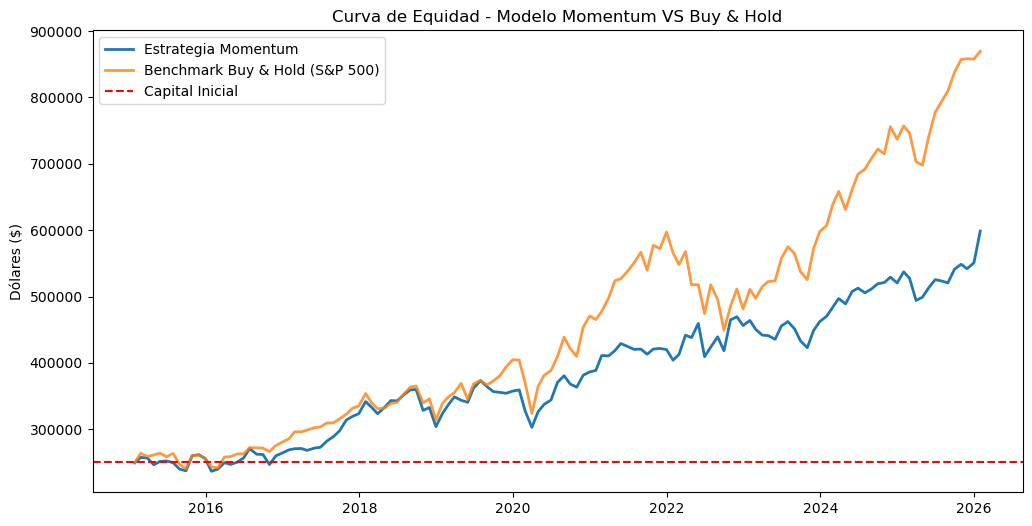

In [38]:
# Simulación de la inversión en SP500
acciones_mercado = capital/precios_sp500_mensual.iloc[0]
inversion_mercado = acciones_mercado*precios_sp500_mensual

#Evolución de la rentabilidad mensual acumulada
plt.figure(figsize=(12,6))

# Graficamos ambas series
plt.plot(precios_momentum_mensual, label='Estrategia Momentum', linewidth=2, color='#1f77b4')
plt.plot(inversion_mercado, label='Benchmark Buy & Hold (S&P 500)', linewidth=2, color='#ff7f0e', alpha=0.8)

# Graficamos que hubiera pasado si no se invirtiese el capital
plt.axhline(y=250000, color='r', linestyle='--', label='Capital Inicial')

plt.title('Curva de Equidad - Modelo Momentum VS Buy & Hold')
plt.ylabel('Dólares ($)')
plt.legend()
plt.show()

Los drawdowns (mayores caídas desde máximos) muestran que a lo largo del periodo es arriesgada la estrategia momentum. Sin embargo, durante la crisis de 2022 las caidas del mercado han sido muy superiores. Tan grande es la diferencia, que por ello, la estrategia Buy & Hold acaba siendo más arriesgada.

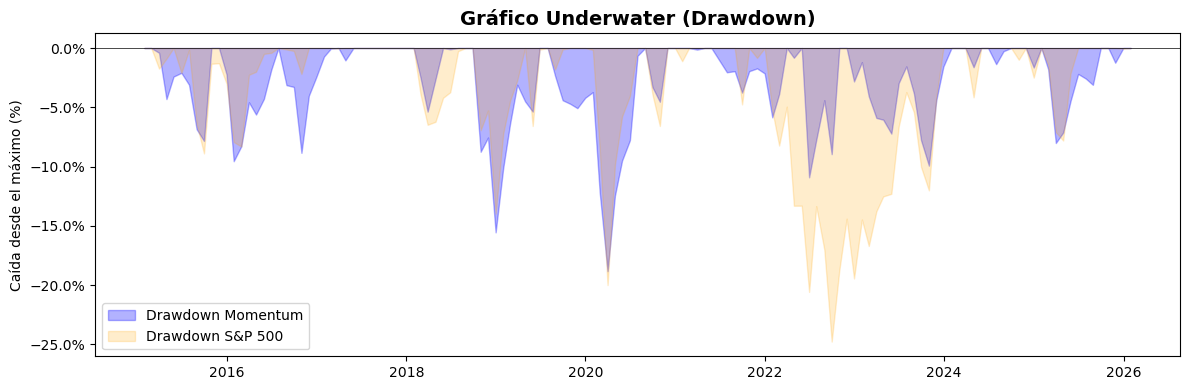

In [39]:
# Calculamos las series de Drawdown (basadas en tus retornos logarítmicos)
def get_drawdown_series(precios):
    # Ya que usas log returns, el wealth acumulado es:
    # Si 'precios' ya es la serie de valor acumulado (como equity_curve):
    rolling_max = precios.cummax()
    drawdown = (precios - rolling_max) / rolling_max
    return drawdown

# Aseguramos que los datos sean 1D usando .values.flatten()
# Esto elimina cualquier estructura de DataFrame o nombres de columnas
dd_momentum = get_drawdown_series(precios_momentum_mensual)
dd_spy = get_drawdown_series(inversion_mercado)

x_axis = dd_momentum.index
y_momentum = dd_momentum.values.flatten()
y_spy = dd_spy.values.flatten()

plt.figure(figsize=(12, 4))

# Graficamos usando los vectores limpios
plt.fill_between(x_axis, y_momentum, 0, color='blue', alpha=0.3, label='Drawdown Momentum')
plt.fill_between(x_axis, y_spy, 0, color='orange', alpha=0.2, label='Drawdown S&P 500')

plt.title('Gráfico Underwater (Drawdown)', fontsize=14, fontweight='bold')
plt.ylabel('Caída desde el máximo (%)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Formatear el eje Y como porcentaje
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend()
plt.tight_layout()
plt.show()

La comparativa de los histogramas de los retornos de ambas estrategias muestran que la distribución de la estrategia Buy & Hold está más desplazada hacia la derecha. Por lo tanto, es una buena confirmación de que **el mercado tiene un mejor rendimiento que la estrategia momentum**.

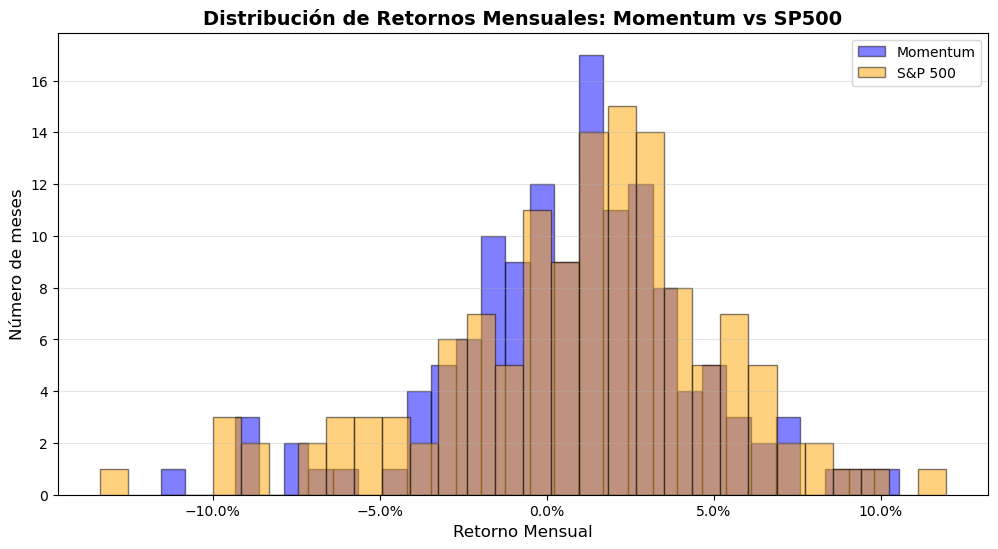

In [40]:
# Histograma de retornos mensuales
# 1. Calculamos los retornos (puedes usar pct_change o tu función get_returns)
ret_estrategia = get_returns(precios_momentum_mensual)
ret_mercado = get_returns(precios_sp500_mensual)

# 2. Configuramos el gráfico
plt.figure(figsize=(12, 6))

# Histograma de la Estrategia
plt.hist(ret_estrategia, bins=30, alpha=0.5, label='Momentum', color='blue', edgecolor='black')

# Histograma del Mercado
plt.hist(ret_mercado, bins=30, alpha=0.5, label='S&P 500', color='orange', edgecolor='black')

# 3. Formato profesional
plt.title('Distribución de Retornos Mensuales: Momentum vs SP500', fontsize=14, fontweight='bold')
plt.xlabel('Retorno Mensual', fontsize=12)
plt.ylabel('Número de meses', fontsize=12)

# Formatear el eje X como porcentaje para que se lea mejor (ej: 5% en lugar de 0.05)
import matplotlib.ticker as mtick
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

De acuerdo con las métricas Kurtosis y Skewness tenemos:
- Las colas del mercado (Skewness) son más extremas que la estrategia momentum. Confirmando, una vez más, que la estrategia buy & Hold ha sido más arriesgada.
- Los eventos anómalos (Kurtosis) son más habituales en la estrategia Buy & Hold.

In [41]:
# Comparativa de métricas de distribuciones entre las dos estrategias (Kurtosis y Skewness)
skew_est = ret_estrategia.skew()
kurt_est = ret_estrategia.kurt()
print('Métricas de distribuciones de la estrategia')
print(f"\tAsimetría (Skewness): {skew_est:.2f}")
print(f"\tCurtosis Excesiva: {kurt_est:.2f}")

skew_mkt = ret_mercado.skew()
kurt_mkt = ret_mercado.kurt()
print()
print('Métricas de distribuciones del mercado')
print(f"\tAsimetría (Skewness): {skew_mkt[0]:.2f}")
print(f"\tCurtosis Excesiva: {kurt_mkt[0]:.2f}")

Métricas de distribuciones de la estrategia
	Asimetría (Skewness): -0.49
	Curtosis Excesiva: 1.25

Métricas de distribuciones del mercado
	Asimetría (Skewness): -0.58
	Curtosis Excesiva: 0.81


C:\Users\mateo\AppData\Local\Temp\ipykernel_11988\1179736292.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\tAsimetría (Skewness): {skew_mkt[0]:.2f}")
C:\Users\mateo\AppData\Local\Temp\ipykernel_11988\1179736292.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\tCurtosis Excesiva: {kurt_mkt[0]:.2f}")


Gráfico que muestra las rentabilidades acumuladas trimestrales de las dos estrategias. Se aprecia cierta correlación pero queda claro que **la estrategia momentum ha sido peor**.

C:\Users\mateo\AppData\Local\Temp\ipykernel_11988\1446396331.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  momentum_trimestral = precios_momentum_mensual.resample('Q').last().iloc[:-1]
C:\Users\mateo\AppData\Local\Temp\ipykernel_11988\1446396331.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  mercado_trimestral = inversion_mercado.resample('Q').last().iloc[:-1]


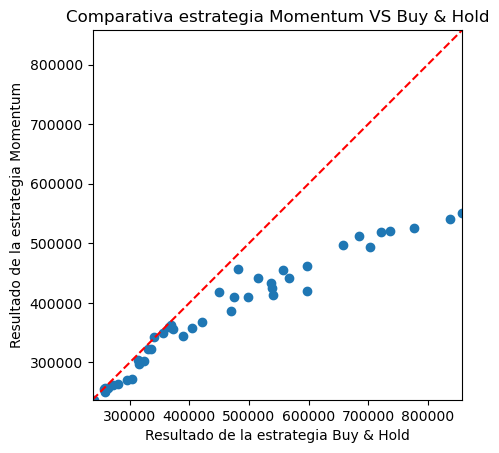

In [42]:
# Análisis de recurrencia de los retornos trimestrales
# Obtenemos los datos trimestrales con la combinación resample('Q').last()
# No seleccinamos la última fecha porque serían datos futuros que no conocemos
momentum_trimestral = precios_momentum_mensual.resample('Q').last().iloc[:-1]
mercado_trimestral = inversion_mercado.resample('Q').last().iloc[:-1]

plt.figure()
plt.scatter(mercado_trimestral, momentum_trimestral)

x = mercado_trimestral.values.flatten()
y = momentum_trimestral.values.flatten()

min_val = np.minimum(x.min(), y.min())
max_val = np.maximum(x.max(), y.max())

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Línea de igualdad
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color = 'red')

plt.title("Comparativa estrategia Momentum VS Buy & Hold")
plt.ylabel("Resultado de la estrategia Momentum")
plt.xlabel("Resultado de la estrategia Buy & Hold")

plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [43]:
porc_momentum_trimestre = np.round((momentum_trimestral.values.flatten() > mercado_trimestral.values.flatten()).sum()*100/len(mercado_trimestral),2)
porc_mercado_trimestre = np.round((mercado_trimestral.values.flatten() > momentum_trimestral.values.flatten()).sum()*100/len(mercado_trimestral),2)
                
print(f"La estrategia momentum es superior al mercado el {porc_momentum_trimestre}% de los trimestres")
print(f"El mercado es superior a la estrategia momentum el {porc_mercado_trimestre}% de los trimestres")

La estrategia momentum es superior al mercado el 2.27% de los trimestres
El mercado es superior a la estrategia momentum el 97.73% de los trimestres


Gráfico que muestra las rentabilidades acumuladas anuales de las dos estrategias. Se aprecia cierta correlación pero queda claro que **la estrategia momentum ha sido peor**.

C:\Users\mateo\AppData\Local\Temp\ipykernel_11988\3462101960.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  momentum_anual = precios_momentum_mensual.resample('Y').last().iloc[:-1]
C:\Users\mateo\AppData\Local\Temp\ipykernel_11988\3462101960.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  mercado_anual = inversion_mercado.resample('Y').last().iloc[:-1]


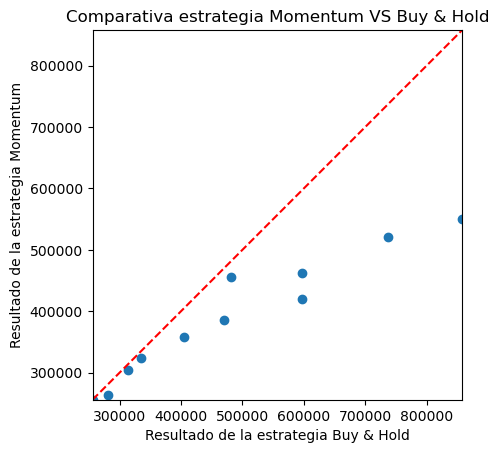

In [44]:
# Análisis de recurrencia de los retornos anuales
# Obtenemos los datos anuales con la combinación resample('Y').last()
# No seleccinamos la última fecha porque serían datos futuros que no conocemos
momentum_anual = precios_momentum_mensual.resample('Y').last().iloc[:-1]
mercado_anual = inversion_mercado.resample('Y').last().iloc[:-1]

plt.figure()

plt.scatter(mercado_anual, momentum_anual)

x = mercado_anual.values.flatten()
y = momentum_anual.values.flatten()

min_val = np.minimum(x.min(), y.min())
max_val = np.maximum(x.max(), y.max())

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Línea de igualdad
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color = 'red')

plt.title("Comparativa estrategia Momentum VS Buy & Hold")
plt.ylabel("Resultado de la estrategia Momentum")
plt.xlabel("Resultado de la estrategia Buy & Hold")

plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [45]:
porc_momentum_anual = np.round((momentum_anual.values.flatten() > mercado_anual.values.flatten()).sum()*100/len(mercado_anual),2)
porc_mercado_anual = np.round((mercado_anual.values.flatten() > momentum_anual.values.flatten()).sum()*100/len(mercado_anual),2)
                
print(f"La estrategia momentum es superior al mercado el {porc_momentum_anual}% de los años")
print(f"El mercado es superior a la estrategia momentum el {porc_mercado_anual}% de los años")

La estrategia momentum es superior al mercado el 0.0% de los años
El mercado es superior a la estrategia momentum el 100.0% de los años


### 5.3. Resumen de resultados

#### 5.3.1. ¿Cómo nos está afectando el sesgo de supervivencia?

El **sesgo de supervivencia** se mitiga porque estamos seleccionando en cada fecha de rebalanceo activos que se encuentren actualmente en el S&P 500 (**universo dinámico**) y, que lo hayan estado en los últimos 13 meses. Si no se hubiera aplicado este filtrado, podríamos haber seleccionado para invertir acciones que no cotizasen (**delisting**) o no estuvieran en el S&P 500 en el periodo de rebalanceo.

#### 5.3.2. ¿Cómo hemos garantizado que no tengamos un problema de look-ahead?

El **look-ahead bias** implica usar datos del futuro que distorsionen el comportamiento del modelo. Está relacionado con otros problemas como el sobreajuste (overfitting). En este caso, mitigamos el look-ahead bias al **calcular los momentum usando los datos desde el mes $t-1$ hasta el $t-r-1$** y al **seleccionar los precios sobre los que se realiza la compraventa de acciones en el rebalanceo**.

Gracias a ello, los rebalanceos se realizan utilizando exclusivamente datos pasados. Las operaciones de rebalanceo se ejecutan el último día hábil bursátil de cada mes.

#### 5.3.3. ¿Crees que existe un problema de overfitting?

**No**, porque no se han optimizado parámetros como el número de meses a tener en cuenta para calcular los momentum. Además, se ha hecho frente al sesgo por supervivencia y el look-ahead bias.

#### 5.3.4. ¿Hemos realizado un rebalanceo irrealista?

**No**, porque los rebalanceos de realizan mensualmente. Si los hicieramos en un periodo inferior el coste de las comisiones sería aún mayor. 

Además, en cada rebalanceo se hace un **filtrado de los activos en los que se puede invertir de acuerdo con las condiciones de presencia en el S&P 500** durante al menos 13 meses.

También, se venden las **acciones de los activos de la cartera que dejen de cotizar o dejen de estar incluidos en el S&P 500**.

Por útlimo, se usan los **precios de apertura (venta) y cierre (compra)** para completar las operaciones de rebalanceo y se simulan las operaciones con un capital considerable. De otro modo, el efecto negativo de las comisiones sería aún mayor.

#### 5.3.5. ¿Cuánto dinero hemos pagado en comisiones de compraventa?

Las comisiones pagadas en cada periodo se almacenan en la variable `comisiones_series`. Las comisiones totales pagadas ascienden a $99.111,16$ $

In [46]:
np.round(comisiones_series.sum(),2)

np.float64(99111.16)